# Fixation Generation Check

In this notebook, we create box plots for fixation durations for each bin.

In [1]:
from ast import literal_eval
import pandas as pd

df_raw = pd.read_csv('1ms_trial_data.csv')

to_drop = pd.read_csv("dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw.loc[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
    & (~df_raw["hidden"])
]

df['RT'] = (df['RT']*1000).astype(int) # RT unit scaling
df['fixation'] = df['fixation'].apply(literal_eval) # String to list as a result of csv saving
df['choice'] = df['choice'].replace({"left": 0, "right": 1}) # Map choice to 0 or 1

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_26726/3236189508.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RT'] = (df['RT']*1000).astype(int) # RT unit scaling
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_26726/3236189508.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fixation'] = df['fixation'].apply(literal_eval) # String to list as a result of csv saving
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_26726/3236189508.py:17: FutureWarning: Down

In [2]:
from simulation import get_corrected_empirical_distributions
import numpy as np

value_diffs = np.unique(df['avgWTP_left'] - df['avgWTP_right'])
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

empirical_distributions = get_corrected_empirical_distributions(
    df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=0.95
)

In [13]:
import matplotlib.pyplot as plt

def plot_fix_box_plots(empirical_distributions, fix_num):
    try:
        fix_dict = empirical_distributions['fixations'][fix_num]
        rvds = sorted(fix_dict.keys())
        data = [fix_dict[rvd] for rvd in rvds]

        n = len(data)
        if n == 0:
            print("No data to plot.")
            return

        horizontal = n > 15

        # --- Styling ---
        box_color = "#1f77b4"   # Matplotlib default blue
        edge_color = "black"    # outlines + median

        boxprops     = dict(facecolor=box_color, edgecolor=edge_color)
        medianprops  = dict(color=edge_color, linewidth=2)
        whiskerprops = dict(color=edge_color)
        capprops     = dict(color=edge_color)

        if horizontal:
            plt.figure(figsize=(10, max(6, n * 0.4)))
            plt.boxplot(
                data,
                vert=False,
                patch_artist=True,
                boxprops=boxprops,
                medianprops=medianprops,
                whiskerprops=whiskerprops,
                capprops=capprops
            )
            plt.yticks(range(1, n + 1), rvds)
            plt.xlabel("Fix. Duration (ms)")
            plt.ylabel("RVD")
        else:
            plt.figure(figsize=(max(12, n * 0.6), 6))
            plt.boxplot(
                data,
                patch_artist=True,
                boxprops=boxprops,
                medianprops=medianprops,
                whiskerprops=whiskerprops,
                capprops=capprops
            )
            plt.xticks(range(1, n + 1), rvds, rotation=45, ha='right')
            plt.ylabel("Fix. Duration (ms)")
            plt.xlabel("RVD")

        plt.title(f"Fixation {fix_num} Empirical Distributions")
        plt.tight_layout()
        plt.show()

    except KeyError:
        print(f"Empirical distributions does not have fixation dictionary {fix_num}.")

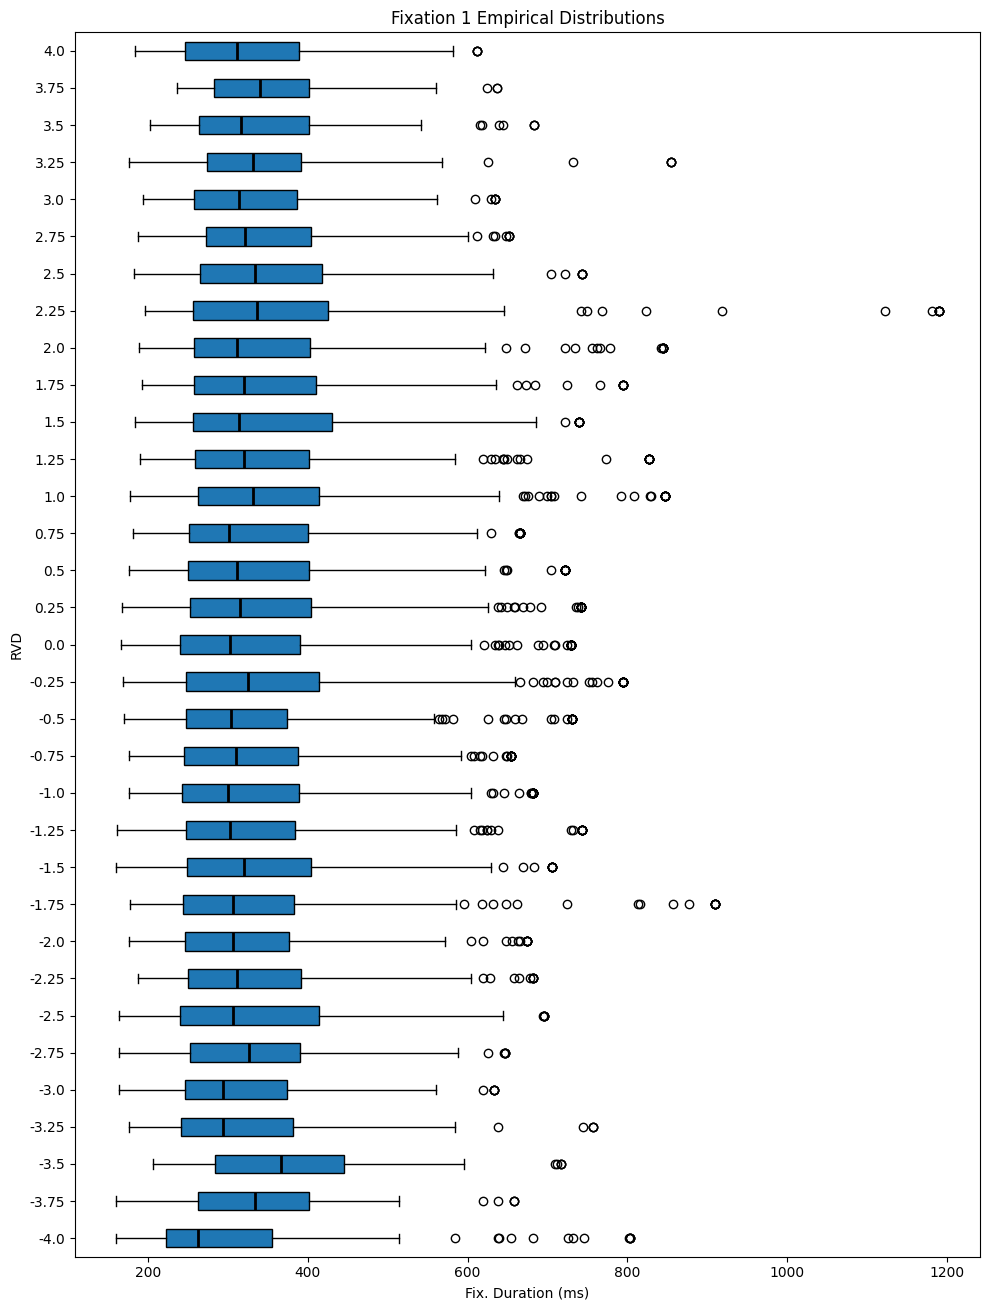

In [14]:
plot_fix_box_plots(empirical_distributions, 1)

In [5]:
import matplotlib.pyplot as plt

def plot_specific_fix_box_plots(empirical_distributions, fix_num, rvds):
    try:
        fix_dict = empirical_distributions['fixations'][fix_num]

        available = empirical_distributions['fixations'][fix_num].keys()
        missing = [r for r in rvds if r not in available]

        if missing:
            raise KeyError(f"RVD keys not found: {missing}")
    
        data = [fix_dict[rvd] for rvd in rvds]

        n = len(data)
        if n == 0:
            print("No data to plot.")
            return

        horizontal = n > 15

        # --- Styling ---
        box_color = "#1f77b4"   # Matplotlib default blue
        edge_color = "black"    # outlines + median

        boxprops     = dict(facecolor=box_color, edgecolor=edge_color)
        medianprops  = dict(color=edge_color, linewidth=2)
        whiskerprops = dict(color=edge_color)
        capprops     = dict(color=edge_color)

        if horizontal:
            plt.figure(figsize=(10, max(6, n * 0.4)))
            plt.boxplot(
                data,
                vert=False,
                patch_artist=True,
                boxprops=boxprops,
                medianprops=medianprops,
                whiskerprops=whiskerprops,
                capprops=capprops
            )
            plt.yticks(range(1, n + 1), rvds)
            plt.xlabel("Value")
            plt.ylabel("RVD")
        else:
            plt.figure(figsize=(max(12, n * 0.6), 6))
            plt.boxplot(
                data,
                patch_artist=True,
                boxprops=boxprops,
                medianprops=medianprops,
                whiskerprops=whiskerprops,
                capprops=capprops
            )
            plt.xticks(range(1, n + 1), rvds, rotation=45, ha='right')
            plt.ylabel("Value")
            plt.xlabel("RVD")

        plt.title(f"Fixation {fix_num} Empirical Distributions")
        plt.tight_layout()
        plt.show()

    except KeyError as e:
        print(e)

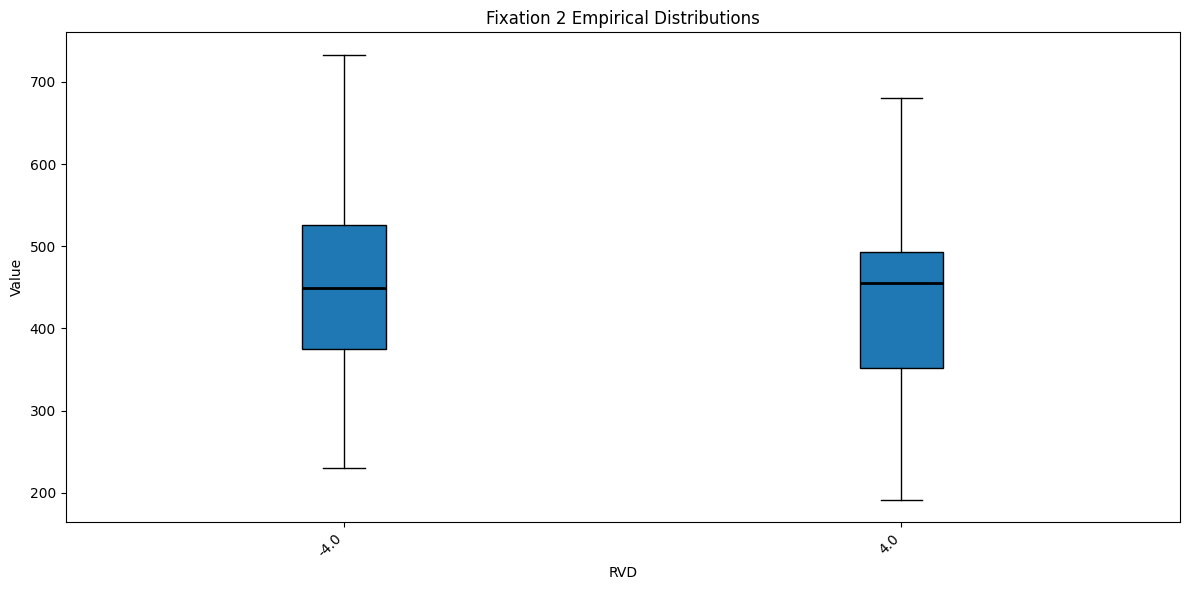

In [6]:
plot_specific_fix_box_plots(empirical_distributions, 2, [-4.0, 4.0])

By observing the box plots, there is no significant difference between all rvds and their fixation duration distributions. Interestingly, with winsorization, there is still an outlier issue.